# Broadsheet: a search engine over 5,368 Financial Times articles, measured

This notebook is the long form behind the Broadsheet site. The site makes the argument in
two minutes; here each step is written out, so a reader can see what was computed, what it
answers and what it cannot answer.

**The corpus.** `ft911_1` to `ft911_15`: the Financial Times articles the TREC disk 4
collection holds for 15 April to 14 May 1991. It is licensed material issued for a
university course and is **not redistributed** by this repository. The files live in
`data/raw/ft911/`, which is git-ignored; `data/raw/SOURCE.md` and `data/raw/SHA256SUMS`
fix the provenance and `site/public/data/meta.json` repeats the hashes. Every cell below
needs that directory to be in place, which is also why CI never runs this notebook.
Nothing here prints the text of an article: headlines, dates and document numbers only,
which is the same rule the published search index follows.

**The judgments.** The NIST Robust 2004 relevance judgments (public) filtered to `FT911-`
document numbers. The topic file holds 250 topics; the judgments reach into this one-month
slice for far fewer, and only topics with at least one relevant document inside the slice
are evaluated (decision D4).

**The question.** Three of them:

1. What does the text look like once a machine has tokenised, stopworded and stemmed it?
2. Does the engine find the right documents, and which weighting finds more of them?
3. What does an evaluation over 2.5 percent of a collection actually let you conclude?

The third is the reason the notebook exists. The course version of this engine was never
scored at all; the interesting result is not that BM25 wins, it is how wide the intervals
around that win are.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = next(
    p
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "pipeline" / "__init__.py").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# One palette for the whole notebook: blue is the course baseline, orange the rebuild's
# BM25, aqua the third ranker, grey the furniture.
BLUE, ORANGE, AQUA, GREY, INK = "#2a78d6", "#eb6834", "#1f9e8f", "#8a97a6", "#20262e"
RANKER_COLOUR = {"tfidf_raw": BLUE, "tfidf_log": AQUA, "bm25": ORANGE}

plt.rcParams.update(
    {
        "figure.dpi": 100,
        "savefig.dpi": 100,
        "figure.autolayout": True,
        "font.size": 9,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 10,
        "axes.titlelocation": "left",
        "grid.color": "#dde3ea",
        "grid.linewidth": 0.5,
        "legend.frameon": False,
    }
)

print("repo root ", ROOT)
print("python    ", sys.version.split()[0])
print("numpy     ", np.__version__)
print("matplotlib", matplotlib.__version__)

repo root  C:\Users\sahaj\OneDrive\Desktop\Experiments\projects\active\broadsheet
python     3.12.10
numpy      2.5.3
matplotlib 3.11.2


In [2]:
from pipeline.constants import (
    BM25_B,
    BM25_K1,
    N_BOOT,
    QRELS_PATH,
    RAW_DIR,
    SEED,
    STOPWORDS_PATH,
    TOPICS_PATH,
)
from pipeline.tokenize import load_stopwords

raw_files = sorted(p for p in RAW_DIR.iterdir() if p.is_file())
raw_mb = sum(p.stat().st_size for p in raw_files) / 1e6
stopwords = load_stopwords()

print(f"corpus directory  {RAW_DIR.relative_to(ROOT).as_posix()}"
      f"  ({len(raw_files)} files, {raw_mb:.1f} MB, not redistributed)")
print(f"topics            {TOPICS_PATH.relative_to(ROOT).as_posix()}")
print(f"judgments         {QRELS_PATH.relative_to(ROOT).as_posix()}")
print(f"stopword list     {STOPWORDS_PATH.relative_to(ROOT).as_posix()}"
      f"  ({len(stopwords)} words, the list the course issued)")
print(f"bootstrap         {N_BOOT:,} resamples, seed {SEED}")
print(f"BM25 defaults     k1 = {BM25_K1}, b = {BM25_B}")

corpus directory  data/raw/ft911  (15 files, 14.7 MB, not redistributed)
topics            data/trec/topics.301-450.601-700.txt
judgments         data/trec/qrels.ft911.txt
stopword list     data/stopwords.txt  (523 words, the list the course issued)
bootstrap         10,000 resamples, seed 20260912
BM25 defaults     k1 = 1.2, b = 0.75


## 2. The corpus

**The question.** How many articles are there, over what period, and how long is one?

`pipeline.parse.load_corpus` reads the SGML records into `Doc(docno, date, headline, text)`
objects sorted by document number. It keeps four fields and drops the rest, and it raises
rather than guessing when a record lacks a document number, a date or a body, so a
malformed file fails the build instead of quietly shrinking the corpus.

In [3]:
from pipeline.parse import load_corpus

docs = load_corpus()
dates = [doc.date for doc in docs]
with_headline = sum(1 for doc in docs if doc.headline)

print(f"documents                  {len(docs):,}")
print(f"files                      {len(raw_files)}")
print(f"date range                 {min(dates)} to {max(dates)}"
      f"  ({len(set(dates))} distinct dates)")
print(f"documents with a headline  {with_headline:,}")
print()
print("five headlines, evenly spaced through the corpus (no article text is printed):")
for i in np.linspace(0, len(docs) - 1, 5).astype(int):
    doc = docs[i]
    print(f"  {doc.docno:<12} {doc.date}  {doc.headline[:70]}")

documents                  5,368


files                      15
date range                 1991-04-15 to 1991-05-14  (25 distinct dates)
documents with a headline  5,368

five headlines, evenly spaced through the corpus (no article text is printed):
  FT911-1      1991-05-14  (CORRECTED) Jubilee of a jet that did what it was designed to do
  FT911-1342   1991-05-07  Letter: No guarantee
  FT911-2684   1991-04-29  Democrats warned on banking reform
  FT911-4026   1991-04-22  Swedish Bonds: Heavy supply of paper pushes up yields
  FT911-5368   1991-04-15  World News in Brief: Ferries disrupted


Document length is measured in **indexed terms** — what survives lowercasing, the digit
rule, the stopword list and the stemmer — not in words of English, because that is the
length BM25 normalises against. The four index treatments (stem or not, stop or not) are
built once here and reused by every section below.

In [4]:
import time

from pipeline.index import build_all
from pipeline.vocab_stats import DOC_LEN_BINS, doc_len_hist, doc_len_summary

started = time.perf_counter()
indexes = build_all(docs, stopwords)
stem_stop = indexes["stem_stop"]
print(f"four indexes built in {time.perf_counter() - started:.1f}s")
print()

lengths = doc_len_summary(stem_stop)
hist = doc_len_hist(stem_stop)

print(f"mean length    {lengths['mean']:.1f} terms")
print(f"median length  {lengths['median']:.0f} terms")
print(f"10th / 90th    {lengths['p10']:.0f} / {lengths['p90']:.0f} terms")
print(f"longest        {lengths['max']:,} terms")
print(f"mean / median  {lengths['mean'] / lengths['median']:.2f}"
      f"  (the gap between them is the right tail)")

four indexes built in 4.3s

mean length    193.1 terms
median length  145 terms
10th / 90th    27 / 437 terms
longest        2,377 terms
mean / median  1.33  (the gap between them is the right tail)


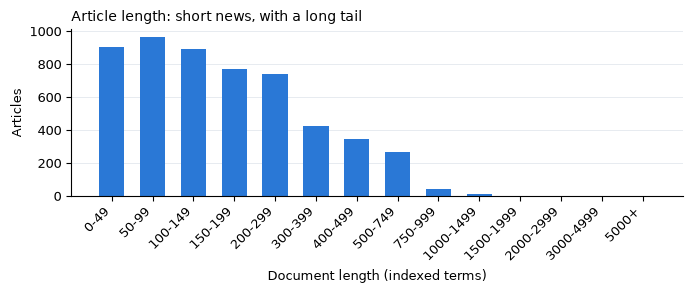

most common band  50-99 terms (964 articles)
under 100 terms   1,866 articles, 35% of the corpus


In [5]:
edges = list(DOC_LEN_BINS)
labels = [f"{lo}-{hi - 1}" for lo, hi in zip(edges, edges[1:])] + [f"{edges[-1]}+"]

fig, ax = plt.subplots(figsize=(7.0, 3.0))
ax.bar(np.arange(len(labels)), hist["counts"], width=0.62, color=BLUE)
ax.set_xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
ax.set_xlabel("Document length (indexed terms)")
ax.set_ylabel("Articles")
ax.set_title("Article length: short news, with a long tail")
ax.grid(axis="x", visible=False)
plt.show()

peak = int(np.argmax(hist["counts"]))
short = sum(hist["counts"][:2])
print(f"most common band  {labels[peak]} terms ({hist['counts'][peak]:,} articles)")
print(f"under 100 terms   {short:,} articles, {short / len(docs):.0%} of the corpus")

The shape is the paper's own: a mass of short market reports and company briefs under a
hundred indexed terms, and a thin tail of long features. It matters twice. Half the
collection is short enough that one term match moves a document a long way up a ranking,
and BM25's length normalisation — the `b` parameter — has a wide range of lengths to act
on. Section 8 shows the surprising thing it does with them.

## 3. From text to terms

**The question.** What does each rule of the course tokenizer cost, and what is left?

The rules, in order: lowercase and split on non-alphanumerics; discard any token
containing a digit; drop the stopwords; Porter-stem what remains. The funnel below comes
from `pipeline.vocab_stats.funnel`, which calls the tokenizer's own regexes rather than a
copy of them, so the table cannot drift from the index it explains.

In [6]:
from pipeline.vocab_stats import funnel

rows = funnel(docs, stopwords)

print(f"{'step':<28} {'types':>10} {'tokens':>12} {'types kept':>12} {'tokens kept':>12}")
print("-" * 78)
previous = None
for row in rows:
    kept_types = "" if previous is None else f"{row['n_types'] / previous['n_types']:.1%}"
    kept_tokens = "" if previous is None else f"{row['n_tokens'] / previous['n_tokens']:.1%}"
    print(f"{row['label']:<28} {row['n_types']:>10,} {row['n_tokens']:>12,}"
          f" {kept_types:>12} {kept_tokens:>12}")
    previous = row

step = {row["step"]: row for row in rows}
lost_digit_tokens = step["raw_alpha"]["n_tokens"] - step["minus_digits"]["n_tokens"]
lost_digit_types = step["raw_alpha"]["n_types"] - step["minus_digits"]["n_types"]
stop_share = 1 - step["minus_stopwords"]["n_tokens"] / step["minus_digits"]["n_tokens"]
stop_types = step["minus_digits"]["n_types"] - step["minus_stopwords"]["n_types"]
stem_cut = 1 - step["stemmed"]["n_types"] / step["minus_stopwords"]["n_types"]

print()
print(f"the digit rule removes {lost_digit_tokens:,} tokens and {lost_digit_types:,} types"
      f" -- every price, date and quantity in a financial paper")
print(f"the stopword list removes {stop_share:.1%} of what is left, but only"
      f" {stop_types:,} types")
print(f"stemming removes no tokens at all and cuts types by {stem_cut:.1%},"
      f" to {step['stemmed']['n_types']:,}")

step                              types       tokens   types kept  tokens kept
------------------------------------------------------------------------------
Alphanumeric tokens              54,164    2,170,486                          
Tokens with digits dropped       48,010    2,068,086        88.6%        95.3%
Stopwords removed                47,506    1,036,714        99.0%        50.1%
Porter stemmed                   32,645    1,036,714        68.7%       100.0%

the digit rule removes 102,400 tokens and 6,154 types -- every price, date and quantity in a financial paper
the stopword list removes 49.9% of what is left, but only 504 types
stemming removes no tokens at all and cuts types by 31.3%, to 32,645


Two rows do most of the work, and they do opposite kinds of work. The stopword list
removes about half of all running text while barely touching the vocabulary — a few
hundred word types are half the corpus. Stemming removes no tokens at all and cuts the
vocabulary by roughly a third. One rule shrinks the postings, the other shrinks the
dictionary.

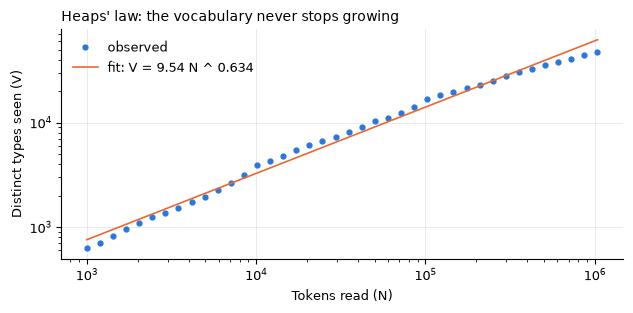

fitted on the unstemmed, stopworded stream:  k = 9.539, beta = 0.63378
observed at the end of the corpus           1,036,714 tokens, 47,506 types
the fit at that point                       61,957 types  (+30%)
largest residual in log10 space             0.1153  (30% in type count; a single power law is an
                                            approximation, and the curve bends)
doubling the corpus would multiply the fitted vocabulary by 2 ** 0.634 = 1.55


In [7]:
from pipeline.vocab_stats import heaps_fit, heaps_points

points = heaps_points(docs, stopwords)
fit = heaps_fit(points)
n_tokens = np.array([p["n_tokens"] for p in points], dtype=float)
n_types = np.array([p["n_types"] for p in points], dtype=float)
fitted = fit["k"] * n_tokens ** fit["beta"]

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(n_tokens, n_types, "o", markersize=3.5, color=BLUE, label="observed")
ax.plot(n_tokens, fitted, "-", linewidth=1.2, color=ORANGE,
        label=f"fit: V = {fit['k']:.2f} N ^ {fit['beta']:.3f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Tokens read (N)")
ax.set_ylabel("Distinct types seen (V)")
ax.set_title("Heaps' law: the vocabulary never stops growing")
ax.legend(loc="upper left")
plt.show()

residual = float(np.abs(np.log10(n_types) - np.log10(fitted)).max())
print(f"fitted on the unstemmed, stopworded stream:  k = {fit['k']:.3f},"
      f" beta = {fit['beta']:.5f}")
print(f"observed at the end of the corpus           {n_tokens[-1]:,.0f} tokens,"
      f" {n_types[-1]:,.0f} types")
print(f"the fit at that point                       {fitted[-1]:,.0f} types"
      f"  ({fitted[-1] / n_types[-1] - 1:+.0%})")
print(f"largest residual in log10 space             {residual:.4f}"
      f"  ({10 ** residual - 1:.0%} in type count; a single power law is an")
print("                                            approximation, and the curve bends)")
print(f"doubling the corpus would multiply the fitted vocabulary by"
      f" 2 ** {fit['beta']:.3f} = {2 ** fit['beta']:.2f}")

Heaps' curve is fitted on the *unstemmed* stream on purpose: stemming is a vocabulary
reduction, and folding it in would measure the stemmer rather than the corpus. A beta well
below 1 is the usual finding, and it is the practical reason the published index prunes
nothing — new text brings new types sublinearly, so a df-1 term costs a few bytes and is
the difference between finding a rare name and shrugging.

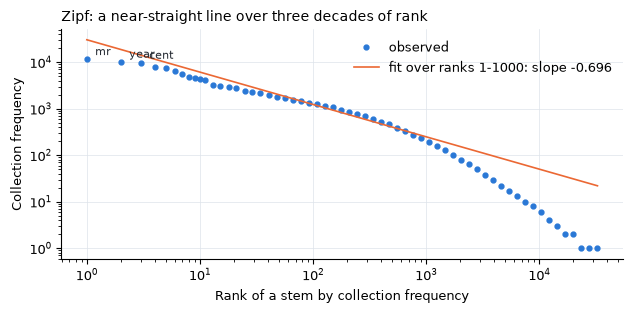

rank 1 is 'mr' with 11,615 occurrences
fitted slope -0.69568; a pure Zipf law would be -1.000, and the head is
flatter than that because the stopword list already removed the flattest part
the last sampled rank is 32,645, frequency 1


In [8]:
from pipeline.vocab_stats import zipf_fit, zipf_points

zpoints = zipf_points(stem_stop)
zfit = zipf_fit(stem_stop)
ranks = np.array([p["rank"] for p in zpoints], dtype=float)
freqs = np.array([p["freq"] for p in zpoints], dtype=float)
line = 10 ** zfit["intercept"] * ranks ** zfit["slope"]

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(ranks, freqs, "o", markersize=3.5, color=BLUE, label="observed")
ax.plot(ranks, line, "-", linewidth=1.2, color=ORANGE,
        label=f"fit over ranks 1-1000: slope {zfit['slope']:.3f}")
for point in zpoints[:3]:
    ax.annotate(point["term"], (point["rank"], point["freq"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8, color=INK)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rank of a stem by collection frequency")
ax.set_ylabel("Collection frequency")
ax.set_title("Zipf: a near-straight line over three decades of rank")
ax.legend(loc="upper right")
plt.show()

head = zpoints[0]
print(f"rank 1 is {head['term']!r} with {head['freq']:,} occurrences")
print(f"fitted slope {zfit['slope']:.5f}; a pure Zipf law would be -1.000, and the head is")
print("flatter than that because the stopword list already removed the flattest part")
print(f"the last sampled rank is {int(ranks[-1]):,}, frequency {int(freqs[-1])}")

In [9]:
from pipeline.vocab_stats import stem_groups, top_terms

groups = stem_groups(docs, stopwords, stem_stop, n_groups=6, n_words=6)
print("the six largest conflations the stemmer makes:")
for group in groups:
    words = ", ".join(word["word"] for word in group["words"])
    print(f"  {group['stem']:<10} {group['n_words']:>3} surface forms   {words}")

heaviest = top_terms(stem_stop, 15)
print()
print("the fifteen heaviest stems in the index:")
print(f"  {'stem':<10} {'collection freq':>16} {'document freq':>14} {'share of articles':>19}")
for row in heaviest:
    print(f"  {row['term']:<10} {row['cf']:>16,} {row['df']:>14,}"
          f" {row['df'] / len(docs):>18.0%}")

mr = next(row for row in heaviest if row["term"] == "mr")
print()
print(f"the heaviest stem in the corpus is {mr['term']!r}: {mr['cf']:,} occurrences in"
      f" {mr['df']:,} of {len(docs):,} articles ({mr['df'] / len(docs):.0%})")

the six largest conflations the stemmer makes:
  commun      18 surface forms   community, communications, communication, communities, communism, communicate
  gener       17 surface forms   general, generally, generation, generating, generated, generous
  oper        13 surface forms   operating, operations, operation, operate, operators, operates
  origin      12 surface forms   original, originally, origin, origins, originated, originality
  continu     11 surface forms   continue, continued, continuing, continues, continuous, continuation
  design      11 surface forms   designed, design, designs, designer, designated, designers

the fifteen heaviest stems in the index:
  stem        collection freq  document freq   share of articles
  mr                   11,615          2,775                52%
  year                 10,215          3,326                62%
  cent                  9,682          2,453                46%
  pound                 8,024          1,994                

The head of that list is the corpus describing itself: `mr`, `year`, `cent`, `pound`,
`compani`. Two things are worth saying plainly.

`mr` is an honorific, not a content word, and the 523-word list the course issued does not
contain it — so it survives into the index as the single heaviest term in the collection.
A list built for newswire would have removed it. The list is kept unchanged (decision D6)
because the rebuild is measuring the course's pipeline; a different list would be
measuring a different engine. Its idf is near zero, so it adds almost nothing to a score,
but it is in every traversal, and it is the clearest evidence here that a stopword list is
a judgement call rather than a fact.

The conflations are Porter working as designed and as advertised: `commun` collapses
*community*, *communications* and *communism* into one term. That is over-stemming, and it
costs precision on any query about one of those senses. Section 9 says what it means for
the numbers.

## 4. Stemmer parity

**The question.** Is this Porter implementation the Porter algorithm, and does the browser
agree with it?

The stemmer is own code in two languages — Python here, TypeScript in `site/src/` —
because NLTK's default mode adds extensions no JavaScript port matches, and one algorithm
in two languages must agree or the demo would rank differently from the published numbers.
Both are tested against Martin Porter's own vocabulary and output files, committed under
`tests/golden/porter/`.

In [10]:
from pipeline.porter import stem

voc = (ROOT / "tests/golden/porter/voc.txt").read_text(encoding="utf-8").split()
expected = (ROOT / "tests/golden/porter/output.txt").read_text(encoding="utf-8").split()
assert len(voc) == len(expected), "the two golden files must line up word for word"

mismatches = [(w, stem(w), want) for w, want in zip(voc, expected) if stem(w) != want]
unchanged = sum(1 for w, want in zip(voc, expected) if w == want)

print(f"words in Porter's vocabulary file   {len(voc):,}")
print(f"mismatches against output.txt       {len(mismatches)}")
print(f"words the algorithm leaves alone    {unchanged:,}"
      f"  ({unchanged / len(voc):.0%})")
print()
for word in ("running", "flies", "agreed", "national", "communication", "chunnel"):
    print(f"  {word:<14} -> {stem(word)}")

words in Porter's vocabulary file   23,531
mismatches against output.txt       0
words the algorithm leaves alone    9,129  (39%)

  running        -> run
  flies          -> fli
  agreed         -> agre
  national       -> nation
  communication  -> commun
  chunnel        -> chunnel


In [11]:
import json

titles = json.loads((ROOT / "tests/golden/topic_titles.json").read_text(encoding="utf-8"))
top10 = json.loads((ROOT / "tests/golden/top10_bm25_title.json").read_text(encoding="utf-8"))
top10_raw = json.loads(
    (ROOT / "tests/golden/top10_tfidf_raw_title.json").read_text(encoding="utf-8")
)
full_ten = sum(1 for hits in top10.values() if len(hits) == 10)

print(f"topic titles in the fixture           {len(titles)}")
print(f"titles that retrieve anything at all  {len(top10)}"
      f"  ({len(titles) - len(top10)} return nothing once stopworded and stemmed)")
print(f"of those, with a full ten             {full_ten}")
print(f"the same fixture for the course tf-idf ranker: {len(top10_raw)} topics")
print()
print("`npm test` in site/ runs the TypeScript stemmer over the same 23,531 words and")
print("compares the browser's top ten -- document order and score -- against these files.")
print("Two implementations that disagreed would undermine every number in this notebook.")

topic titles in the fixture           250
titles that retrieve anything at all  243  (7 return nothing once stopworded and stemmed)
of those, with a full ten             238
the same fixture for the course tf-idf ranker: 243 topics

`npm test` in site/ runs the TypeScript stemmer over the same 23,531 words and
compares the browser's top ten -- document order and score -- against these files.
Two implementations that disagreed would undermine every number in this notebook.


## 5. The index

**The question.** What does the inverted index actually hold?

A posting is `(document index, term frequency)` and `postings[term]` is ascending by
document index. The distribution of posting-list lengths is the distribution of document
frequency, and it is the most lopsided thing in the project.

In [12]:
from pipeline.vocab_stats import POSTING_BINS, longest, posting_hist, posting_summary

phist = posting_hist(stem_stop)
summary = posting_summary(stem_stop)

print(f"terms in the index    {summary['n_terms']:,}")
print(f"postings              {summary['n_postings']:,}")
print(f"mean list length      {summary['mean_len']:.1f} documents")
print(f"median list length    {summary['median_len']:.0f} documents")
print(f"longest list          {summary['max_len']:,} documents")
print(f"terms with df = 1     {summary['df1_share']:.1%} of the vocabulary")
print(f"avgdl                 {stem_stop.avgdl:.2f} terms"
      f"  (the length BM25 normalises against)")

terms in the index    32,645
postings              672,668
mean list length      20.6 documents
median list length    2 documents
longest list          3,326 documents
terms with df = 1     44.1% of the vocabulary
avgdl                 193.13 terms  (the length BM25 normalises against)


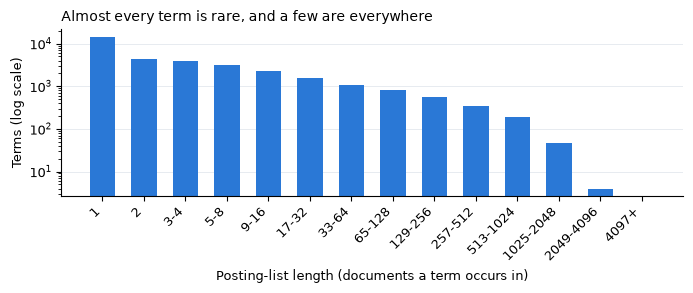

the ten longest posting lists:
  year       df  3,326  (62% of all articles)
  mr         df  2,775  (52% of all articles)
  cent       df  2,453  (46% of all articles)
  compani    df  2,283  (43% of all articles)
  market     df  2,013  (38% of all articles)
  pound      df  1,994  (37% of all articles)
  yesterdai  df  1,985  (37% of all articles)
  group      df  1,865  (35% of all articles)
  time       df  1,798  (33% of all articles)
  govern     df  1,708  (32% of all articles)


In [13]:
edges = list(POSTING_BINS)
labels = [f"{lo}-{hi - 1}" if hi - 1 > lo else f"{lo}" for lo, hi in zip(edges, edges[1:])]
labels.append(f"{edges[-1]}+")

fig, ax = plt.subplots(figsize=(7.0, 3.0))
ax.bar(np.arange(len(labels)), phist["counts"], width=0.62, color=BLUE)
ax.set_yscale("log")
ax.set_xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
ax.set_xlabel("Posting-list length (documents a term occurs in)")
ax.set_ylabel("Terms (log scale)")
ax.set_title("Almost every term is rare, and a few are everywhere")
ax.grid(axis="x", visible=False)
plt.show()

print("the ten longest posting lists:")
for row in longest(stem_stop, 10):
    print(f"  {row['term']:<10} df {row['df']:>6,}"
          f"  ({row['df'] / len(docs):.0%} of all articles)")

Nearly half the vocabulary occurs in exactly one document. Those terms contribute nothing
to most queries and cost almost nothing to keep, which is why the published browser index
prunes nothing. The other end is where the cost is: a query term with a list of several
thousand documents is most of the work of answering the query, and carries the least
information while doing it.

## 6. Three rankers, and one query that fails

**The question.** What are the three weightings, and what does a ranking look like from
the inside?

Write $N$ for the number of documents, $\mathrm{df}_t$ for the number holding term $t$,
$\mathrm{tf}_{t,d}$ for the count of $t$ in document $d$, $\mathrm{dl}_d$ for the length of
$d$ in indexed terms and $\overline{\mathrm{dl}}$ for the mean of those lengths.

**`tfidf_raw`, the course weighting.** Raw term count times idf, on both sides, cosine
normalised:

$$w_{t,d} = \mathrm{tf}_{t,d}\cdot\log_{10}\frac{N}{\mathrm{df}_t},
\qquad
\mathrm{score}(q,d) = \frac{\sum_t w_{t,q}\,w_{t,d}}
{\lVert w_{\cdot,q}\rVert\ \lVert w_{\cdot,d}\rVert}$$

**`tfidf_log`.** The textbook damping of the term count, everything else unchanged:

$$w_{t,d} = \bigl(1 + \log_{10}\mathrm{tf}_{t,d}\bigr)\cdot
\log_{10}\frac{N}{\mathrm{df}_t}$$

**`bm25`.** A saturating term-frequency component and explicit length normalisation, with
the non-negative idf variant:

$$\mathrm{score}(q,d) = \sum_t \mathrm{qtf}_t\cdot
\ln\!\left(\frac{N-\mathrm{df}_t+0.5}{\mathrm{df}_t+0.5}+1\right)\cdot
\frac{\mathrm{tf}_{t,d}\,(k_1+1)}
{\mathrm{tf}_{t,d}+k_1\!\left(1-b+b\,\dfrac{\mathrm{dl}_d}{\overline{\mathrm{dl}}}\right)}$$

with $k_1 = 1.2$ and $b = 0.75$ as the published defaults. The difference that matters is
shape: cosine rewards a repeated term nearly linearly, BM25 saturates it, and only BM25
knows how long the document is.

The worked example is topic 352, *British Chunnel impact* — the best single illustration
in the collection of what a bag-of-stems engine cannot do.

In [14]:
from pipeline.rank import RANKERS, Scorer
from pipeline.tokenize import analyze
from pipeline.topics import load_qrels, load_topics

topics = load_topics()
qrels = load_qrels(docnos=set(stem_stop.docnos))
topic = next(t for t in topics if t.num == 352)
query_terms = analyze(topic.title, stopwords, stem=True)

print(f"topic {topic.num}: {topic.title!r}")
print(f"analysed to {query_terms}")
print()
print(f"  {'stem':<10} {'df':>7} {'share of the corpus':>21}")
for term in query_terms:
    df = stem_stop.df(term)
    print(f"  {term:<10} {df:>7,} {df / len(docs):>20.1%}")
print()
print(f"'chunnel' has df {stem_stop.df('chunnel')}: the Financial Times did not use the word")
print("in 1991, it wrote 'the Channel tunnel'. The query that actually runs is")
print("'british impact', and the ranking below is the ranking of that query, not of the")
print("topic a reader had in mind.")

topic 352: 'British Chunnel impact'
analysed to ['british', 'chunnel', 'impact']

  stem            df   share of the corpus
  british        906                16.9%
  chunnel          0                 0.0%
  impact         264                 4.9%

'chunnel' has df 0: the Financial Times did not use the word
in 1991, it wrote 'the Channel tunnel'. The query that actually runs is
'british impact', and the ranking below is the ranking of that query, not of the
topic a reader had in mind.


In [15]:
relevant = {docno for docno, value in qrels.get(topic.num, {}).items() if value == 1}

for ranker in ("bm25", "tfidf_raw"):
    scorer = Scorer(stem_stop, ranker)
    print(f"{RANKERS[ranker]} -- top five for topic {topic.num}")
    for rank, (doc_idx, score) in enumerate(scorer.rank(query_terms, 5), start=1):
        doc = docs[doc_idx]
        mark = "  <- judged relevant" if doc.docno in relevant else ""
        print(f"  {rank}. {score:7.4f}  {doc.docno:<12} {doc.date}"
              f"  {doc.headline[:54]}{mark}")
    print()

print(f"topic {topic.num} has {len(relevant)} relevant document(s) in this slice and"
      f" {len(qrels.get(topic.num, {}))} judged documents")

BM25 -- top five for topic 352
  1.  6.6119  FT911-3618   1991-04-24  UK Company News: British Fittings up at Pounds 6.2m
  2.  6.3814  FT911-5179   1991-04-16  Leading Article: The trouble with insurance
  3.  5.9592  FT911-91     1991-05-14  Small companies may lose in EC public deals race
  4.  5.8886  FT911-2803   1991-04-27  Motoring: Audi launch
  5.  5.4337  FT911-1768   1991-05-03  Leading Article: A spring of discontent

tf-idf cosine (course weighting) -- top five for topic 352
  1.  0.2064  FT911-3246   1991-04-25  Planning move
  2.  0.1765  FT911-4701   1991-04-18  International Company News: Billiton incurs 35% fall
  3.  0.1539  FT911-437    1991-05-11  PowerGen may halve order from British Coal
  4.  0.1421  FT911-3618   1991-04-24  UK Company News: British Fittings up at Pounds 6.2m
  5.  0.1357  FT911-3866   1991-04-23  Management (The Growing Business): Clubbing together i

topic 352 has 2 relevant document(s) in this slice and 36 judged documents


In [16]:
scorer = Scorer(stem_stop, "bm25")
top_idx, top_score = scorer.rank(query_terms, 1)[0]
explain = scorer.explain(query_terms, top_idx)

print(f"why {docs[top_idx].docno} ranked first under BM25 (score {top_score:.4f})")
print(f"  headline  {docs[top_idx].headline[:66]}")
print(f"  length    {stem_stop.doc_len[top_idx]} indexed terms"
      f"  (avgdl {stem_stop.avgdl:.1f})")
print()
print(f"  {'stem':<10} {'qtf':>4} {'tf':>4} {'df':>8} {'idf':>9}"
      f" {'contribution':>13} {'share':>7}")
for row in explain:
    print(f"  {row['term']:<10} {row['qtf']:>4} {row['tf']:>4} {row['df']:>8,}"
          f" {row['idf']:>9.4f} {row['contribution']:>13.4f}"
          f" {row['contribution'] / top_score:>6.0%}")
print(f"  {'total':<10} {'':>4} {'':>4} {'':>8} {'':>9}"
      f" {sum(row['contribution'] for row in explain):>13.4f}")
print()
print("The rows sum to the score, which is what the site's explain panel shows a visitor.")
print("Here they also show the failure: the rarer of the two surviving stems carries most")
print("of the score, and neither of them is the word the topic is about.")

why FT911-3618 ranked first under BM25 (score 6.6119)
  headline  UK Company News: British Fittings up at Pounds 6.2m
  length    63 indexed terms  (avgdl 193.1)

  stem        qtf   tf       df       idf  contribution   share
  british       1    1      906    1.7788        2.4557    37%
  impact        1    1      264    3.0106        4.1562    63%
  total                                          6.6119

The rows sum to the score, which is what the site's explain panel shows a visitor.
Here they also show the failure: the rarer of the two surviving stems carries most
of the score, and neither of them is the word the topic is about.


This is the honest shape of the result. The engine did not malfunction; it answered the
query it was given, which lost its only specific term at the vocabulary boundary. A phrase
index would not have helped either. Only a synonym list or a query-expansion step would,
and this engine has neither, by design (decision R5).

## 7. Does it find the right articles?

**The question.** Against the judgments, which weighting retrieves more relevant
documents, and how sure can anyone be?

`pipeline.runs.build_runs` scores everything once: nine main runs (three rankers by three
query fields), four treatment runs (BM25 on the title over each stem/stopword index),
twenty-five BM25 grid cells and eight paired comparisons. Every mean carries a 95 percent
percentile bootstrap interval over topics — 10,000 resamples, one fixed seed (decision S1)
— because per-topic average precision is skewed and a t interval would be the wrong shape.

Two conventions decide what the numbers mean. A document nobody judged counts as not
relevant (D5), which biases every run downwards by an unknown amount, so `judged@10` — the
share of the top ten any assessor looked at — is printed beside every metric. And average
precision divides by the number of relevant documents **in this slice** (S2), so a run that
finds one of three cannot score above a third however it orders them.

In [17]:
from pipeline.runs import RUN_KEYS, build_runs

started = time.perf_counter()
results = build_runs(indexes, topics, qrels, stopwords)
print(f"scored 9 runs, 4 treatments, 25 grid cells and 8 comparisons in"
      f" {time.perf_counter() - started:.1f}s")

counts = results["counts"]
topics_eval = results["topics_eval"]
print()
print(f"topics in the topic file                      {counts['n_topics_all']}")
print(f"topics with a relevant document in the slice  {counts['n_topics']}"
      f"   <- every mean below is over these")
print(f"of those, with exactly one relevant document  {counts['n_single_rel_topics']}")
print(f"relevant (document, topic) pairs              {counts['n_rel_total']}")
print(f"judged documents inside the slice             {counts['n_judged_docs']:,}"
      f" of {len(docs):,}  ({counts['n_judged_docs'] / len(docs):.0%})")

scored 9 runs, 4 treatments, 25 grid cells and 8 comparisons in 6.1s

topics in the topic file                      250
topics with a relevant document in the slice  71   <- every mean below is over these
of those, with exactly one relevant document  36
relevant (document, topic) pairs              186
judged documents inside the slice             1,844 of 5,368  (34%)


In [18]:
from pipeline.topics import FIELDS


def interval(run_key, metric):
    return results["main"][run_key]["metrics"][metric]


header = f"{'run':<28}" + "".join(
    f"{name:>24}" for name in ("MAP", "P@10", "nDCG@10", "judged@10")
)
print(header)
print("-" * len(header))
for key in RUN_KEYS:
    cells = []
    for metric in ("map", "p10", "ndcg10", "judged10"):
        stat = interval(key, metric)
        cells.append(f"{stat['mean']:.3f} [{stat['lo']:.3f}, {stat['hi']:.3f}]")
    print(f"{key:<28}" + "".join(f"{cell:>24}" for cell in cells))

best = max(RUN_KEYS, key=lambda k: interval(k, "map")["mean"])
worst = min(RUN_KEYS, key=lambda k: interval(k, "map")["mean"])
judged_lo = min(interval(k, "judged10")["mean"] for k in RUN_KEYS)
judged_hi = max(interval(k, "judged10")["mean"] for k in RUN_KEYS)
print()
print(f"best MAP   {best:<28} {interval(best, 'map')['mean']:.4f}")
print(f"worst MAP  {worst:<28} {interval(worst, 'map')['mean']:.4f}")
print(f"judged@10 runs from {judged_lo:.1%} to {judged_hi:.1%}: about half of what these")
print("runs put in a top ten was never looked at by an assessor, so every metric here is a")
print("lower bound of unknown tightness")

run                                              MAP                    P@10                 nDCG@10               judged@10
----------------------------------------------------------------------------------------------------------------------------
tfidf_raw|title                 0.291 [0.218, 0.369]    0.104 [0.075, 0.137]    0.335 [0.254, 0.419]    0.420 [0.366, 0.475]
tfidf_raw|title_desc            0.303 [0.228, 0.381]    0.111 [0.083, 0.142]    0.358 [0.279, 0.440]    0.472 [0.420, 0.525]
tfidf_raw|title_desc_narr       0.323 [0.246, 0.402]    0.110 [0.080, 0.142]    0.367 [0.283, 0.451]    0.470 [0.415, 0.525]
tfidf_log|title                 0.284 [0.209, 0.363]    0.101 [0.073, 0.132]    0.331 [0.248, 0.416]    0.399 [0.346, 0.452]
tfidf_log|title_desc            0.292 [0.217, 0.374]    0.111 [0.083, 0.142]    0.343 [0.261, 0.429]    0.461 [0.406, 0.514]
tfidf_log|title_desc_narr       0.331 [0.253, 0.414]    0.121 [0.092, 0.152]    0.390 [0.306, 0.476]    0.442 [0.396, 0.487]


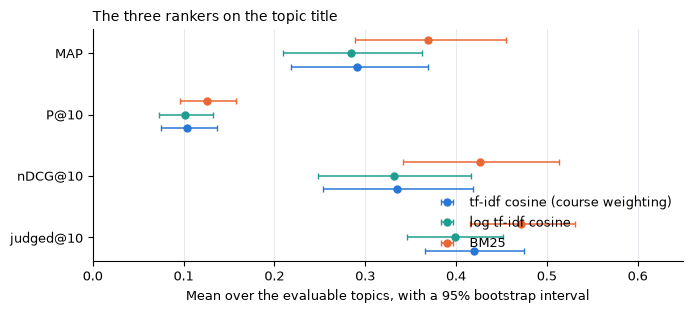

BM25 MAP           0.3696 [0.2887, 0.4547]
course tf-idf MAP  0.2912 [0.2184, 0.3692]
the two intervals overlap over a width of 0.0805 MAP, which is why this
chart on its own cannot settle the comparison


In [19]:
title_runs = [f"{ranker}|title" for ranker in RANKERS]
metrics = [("map", "MAP"), ("p10", "P@10"), ("ndcg10", "nDCG@10"), ("judged10", "judged@10")]
offsets = dict(zip(title_runs, (0.22, 0.0, -0.22)))

fig, ax = plt.subplots(figsize=(7.0, 3.2))
for key in title_runs:
    ranker = key.split("|")[0]
    ys, xs, lo, hi = [], [], [], []
    for position, (metric, _) in enumerate(metrics):
        stat = interval(key, metric)
        ys.append(position + offsets[key])
        xs.append(stat["mean"])
        lo.append(stat["mean"] - stat["lo"])
        hi.append(stat["hi"] - stat["mean"])
    ax.errorbar(xs, ys, xerr=[lo, hi], fmt="o", markersize=5, color=RANKER_COLOUR[ranker],
                ecolor=RANKER_COLOUR[ranker], elinewidth=1.1, capsize=2.5,
                label=RANKERS[ranker])
ax.set_yticks(range(len(metrics)), [label for _, label in metrics])
ax.invert_yaxis()
ax.set_xlim(0, 0.65)
ax.set_xlabel("Mean over the evaluable topics, with a 95% bootstrap interval")
ax.set_title("The three rankers on the topic title")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
plt.show()

bm25_map = interval("bm25|title", "map")
raw_map = interval("tfidf_raw|title", "map")
overlap = min(bm25_map["hi"], raw_map["hi"]) - max(bm25_map["lo"], raw_map["lo"])
print(f"BM25 MAP           {bm25_map['mean']:.4f} [{bm25_map['lo']:.4f}, {bm25_map['hi']:.4f}]")
print(f"course tf-idf MAP  {raw_map['mean']:.4f} [{raw_map['lo']:.4f}, {raw_map['hi']:.4f}]")
print(f"the two intervals overlap over a width of {overlap:.4f} MAP, which is why this")
print("chart on its own cannot settle the comparison")

Those intervals are wide and they overlap heavily. The width is topic-difficulty variance:
some topics are easy for every run and some are hopeless for every run, so resampling
topics moves the mean a long way. It is not a statement that the rankers are
indistinguishable — it is a statement that this chart cannot tell. The per-topic
distribution shows where the variance lives, and the paired comparison after it removes it.

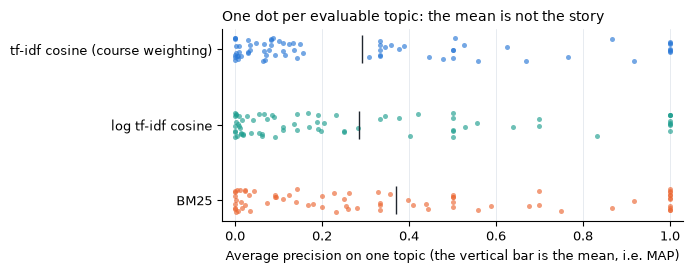

BM25 on the title, over 71 topics:
  AP exactly zero   6 topics
  AP below 0.1      23 topics
  AP above 0.9      12 topics
  median AP         0.2586    mean (MAP) 0.3696
the median is below the mean: a minority of topics the engine answers almost perfectly carries the average,
and a long list of topics it answers not at all sits under it


In [20]:
ap = {key: results["main"][key]["per_topic"]["ap"] for key in RUN_KEYS}
rng = np.random.default_rng(SEED)

fig, ax = plt.subplots(figsize=(7.0, 2.8))
for position, key in enumerate(title_runs):
    values = ap[key]
    jitter = rng.uniform(-0.16, 0.16, size=values.size)
    ax.scatter(values, np.full(values.size, position) + jitter, s=13, alpha=0.65,
               color=RANKER_COLOUR[key.split("|")[0]], linewidths=0)
    ax.plot([values.mean()], [position], marker="|", markersize=20, color=INK)
ax.set_yticks(range(len(title_runs)), [RANKERS[k.split("|")[0]] for k in title_runs])
ax.invert_yaxis()
ax.set_xlim(-0.03, 1.03)
ax.set_xlabel("Average precision on one topic (the vertical bar is the mean, i.e. MAP)")
ax.set_title("One dot per evaluable topic: the mean is not the story")
ax.grid(axis="y", visible=False)
plt.show()

values = ap["bm25|title"]
print(f"BM25 on the title, over {values.size} topics:")
print(f"  AP exactly zero   {int((values == 0).sum())} topics")
print(f"  AP below 0.1      {int((values < 0.1).sum())} topics")
print(f"  AP above 0.9      {int((values > 0.9).sum())} topics")
print(f"  median AP         {np.median(values):.4f}    mean (MAP) {values.mean():.4f}")
print(f"the median is {'below' if np.median(values) < values.mean() else 'above'} the mean:"
      " a minority of topics the engine answers almost perfectly carries the average,")
print("and a long list of topics it answers not at all sits under it")

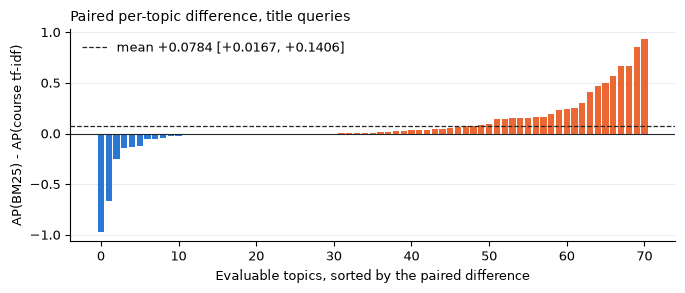

BM25 vs course tf-idf (title)
  mean difference in AP  +0.0784   95% interval [+0.0167, +0.1406]
  wins / losses / ties   40 / 17 / 14  of 71 topics
  largest single win     +0.9333     largest single loss -0.9677
  interval excludes zero: yes -- pairing cancels the topic-difficulty variance that made the chart above
  inconclusive, because both rankers are scored on the same topic and only the
  difference is resampled


In [21]:
pair = next(p for p in results["comparisons"] if p["key"] == "bm25_vs_raw")
diffs = np.array([row["diff"] for row in pair["per_topic"]], dtype=float)
ordered = np.sort(diffs)
colours = [ORANGE if d > 0 else BLUE if d < 0 else GREY for d in ordered]

fig, ax = plt.subplots(figsize=(7.0, 3.0))
ax.bar(np.arange(ordered.size), ordered, width=0.8, color=colours)
ax.axhline(0.0, color=INK, linewidth=0.8)
ax.axhline(pair["mean_diff"], color=INK, linewidth=0.9, linestyle="--",
           label=f"mean {pair['mean_diff']:+.4f}"
                 f" [{pair['lo']:+.4f}, {pair['hi']:+.4f}]")
ax.set_xlabel("Evaluable topics, sorted by the paired difference")
ax.set_ylabel("AP(BM25) - AP(course tf-idf)")
ax.set_title("Paired per-topic difference, title queries")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
plt.show()

total = pair["wins"] + pair["losses"] + pair["ties"]
print(pair["label"])
print(f"  mean difference in AP  {pair['mean_diff']:+.4f}"
      f"   95% interval [{pair['lo']:+.4f}, {pair['hi']:+.4f}]")
print(f"  wins / losses / ties   {pair['wins']} / {pair['losses']} / {pair['ties']}"
      f"  of {total} topics")
print(f"  largest single win     {ordered[-1]:+.4f}"
      f"     largest single loss {ordered[0]:+.4f}")
print(f"  interval excludes zero: {'yes' if pair['lo'] > 0 else 'no'}"
      " -- pairing cancels the topic-difficulty variance that made the chart above")
print("  inconclusive, because both rankers are scored on the same topic and only the")
print("  difference is resampled")

This is the one comparison in the project that is reasonably solid: BM25 wins on well over
half the topics and the interval on the mean difference stays clear of zero. It is still an
interval over 71 topics, and every other comparison below is a narrower effect whose
interval straddles zero or barely clears it.

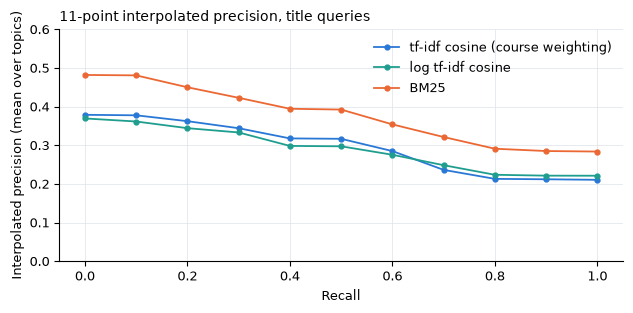

tf-idf cosine (course weighting) precision at recall 0.0 0.3788   at recall 1.0 0.2106
log tf-idf cosine              precision at recall 0.0 0.3694   at recall 1.0 0.2212
BM25                           precision at recall 0.0 0.4820   at recall 1.0 0.2838

The curves keep their order at every recall level, and none starts above 0.5: even
at the very top of a ranking, most of what this engine returns for these topics is
not a judged-relevant document.


In [22]:
from pipeline.evaluate import RECALL_LEVELS

fig, ax = plt.subplots(figsize=(6.4, 3.2))
for key in title_runs:
    curve = results["main"][key]["interp"].mean(axis=0)
    ax.plot(RECALL_LEVELS, curve, marker="o", markersize=3.5, linewidth=1.3,
            color=RANKER_COLOUR[key.split("|")[0]], label=RANKERS[key.split("|")[0]])
ax.set_xlabel("Recall")
ax.set_ylabel("Interpolated precision (mean over topics)")
ax.set_ylim(0, 0.6)
ax.set_title("11-point interpolated precision, title queries")
ax.legend(loc="upper right")
plt.show()

for key in title_runs:
    curve = results["main"][key]["interp"].mean(axis=0)
    print(f"{RANKERS[key.split('|')[0]]:<30} precision at recall 0.0 {curve[0]:.4f}"
          f"   at recall 1.0 {curve[-1]:.4f}")
print()
print("The curves keep their order at every recall level, and none starts above 0.5: even")
print("at the very top of a ranking, most of what this engine returns for these topics is")
print("not a judged-relevant document.")

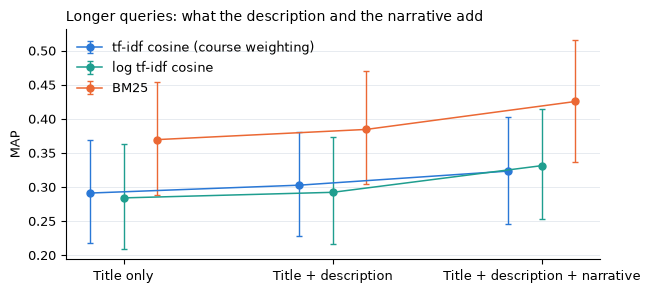

BM25: title + description vs title                      +0.0150 [-0.0350, +0.0652]  29W/25L/17T  straddles zero
BM25: title + description + narrative vs title          +0.0559 [+0.0000, +0.1136]  33W/22L/16T  excludes zero
course tf-idf: title + description + narrative vs title +0.0323 [-0.0157, +0.0820]  32W/28L/11T  straddles zero

The narrative field's interval clears zero by 0.000008. That is not a
result. The honest sentence is that longer queries help on average and the interval
is compatible with essentially no effect.


In [23]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(len(FIELDS))
for offset, ranker in zip((-0.16, 0.0, 0.16), RANKERS):
    stats = [interval(f"{ranker}|{field}", "map") for field in FIELDS]
    means = [s["mean"] for s in stats]
    lo = [s["mean"] - s["lo"] for s in stats]
    hi = [s["hi"] - s["mean"] for s in stats]
    ax.errorbar(x + offset, means, yerr=[lo, hi], fmt="o-", markersize=5, linewidth=1.1,
                color=RANKER_COLOUR[ranker], ecolor=RANKER_COLOUR[ranker], elinewidth=1.0,
                capsize=2.5, label=RANKERS[ranker])
ax.set_xticks(x, list(FIELDS.values()))
ax.set_ylabel("MAP")
ax.set_title("Longer queries: what the description and the narrative add")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
plt.show()

for key in ("desc_vs_title", "narr_vs_title", "raw_narr_vs_title"):
    p = next(q for q in results["comparisons"] if q["key"] == key)
    verdict = "excludes zero" if p["lo"] > 0 else "straddles zero"
    print(f"{p['label']:<55} {p['mean_diff']:+.4f}"
          f" [{p['lo']:+.4f}, {p['hi']:+.4f}]"
          f"  {p['wins']}W/{p['losses']}L/{p['ties']}T  {verdict}")
narr = next(q for q in results["comparisons"] if q["key"] == "narr_vs_title")
print()
print(f"The narrative field's interval clears zero by {narr['lo']:.6f}. That is not a")
print("result. The honest sentence is that longer queries help on average and the interval")
print("is compatible with essentially no effect.")

In [24]:
from pipeline.constants import TREATMENT_LABELS, TREATMENTS

print("BM25 on the topic title over each of the four index treatments")
print(f"{'treatment':<32} {'index terms':>12} {'MAP':>24} {'P@10':>24}")
print("-" * 94)
for key in TREATMENTS:
    stats = results["treatments"][key]["metrics"]
    map_stat, p10_stat = stats["map"], stats["p10"]
    map_cell = f"{map_stat['mean']:.4f} [{map_stat['lo']:.4f}, {map_stat['hi']:.4f}]"
    p10_cell = f"{p10_stat['mean']:.4f} [{p10_stat['lo']:.4f}, {p10_stat['hi']:.4f}]"
    print(f"{TREATMENT_LABELS[key]:<32} {len(indexes[key].postings):>12,}"
          f" {map_cell:>24} {p10_cell:>24}")

print()
for key in ("stem_vs_nostem", "stop_vs_nostop"):
    p = next(q for q in results["comparisons"] if q["key"] == key)
    print(f"{p['label']:<46} {p['mean_diff']:+.4f}"
          f" [{p['lo']:+.4f}, {p['hi']:+.4f}]"
          f"  {p['wins']}W/{p['losses']}L/{p['ties']}T")
stop = next(q for q in results["comparisons"] if q["key"] == "stop_vs_nostop")
stop_total = stop["wins"] + stop["losses"] + stop["ties"]
print()
print(f"Removing stopwords changes nothing at all on {stop['ties']} of {stop_total} topics:")
print("a three-word title rarely contains one. Stemming is worth more than stopping, and")
print("neither effect is separable from noise at this number of topics.")

BM25 on the topic title over each of the four index treatments
treatment                         index terms                      MAP                     P@10
----------------------------------------------------------------------------------------------
Stemmed, stopwords removed             32,645  0.3696 [0.2887, 0.4547]  0.1254 [0.0958, 0.1577]
Unstemmed, stopwords removed           47,506  0.3376 [0.2585, 0.4210]  0.1085 [0.0831, 0.1380]
Stemmed, stopwords kept                32,929  0.3613 [0.2825, 0.4442]  0.1239 [0.0958, 0.1549]
Unstemmed, stopwords kept              48,010  0.3287 [0.2528, 0.4103]  0.1070 [0.0817, 0.1366]

BM25: stemmed vs unstemmed (stopwords removed) +0.0320 [-0.0040, +0.0722]  30W/18L/23T
BM25: stopwords removed vs kept (stemmed)      +0.0083 [-0.0020, +0.0248]  22W/17L/32T

Removing stopwords changes nothing at all on 32 of 71 topics:
a three-word title rarely contains one. Stemming is worth more than stopping, and
neither effect is separable from noise at 

## 8. Tuning BM25, and why the best cell is not a result

**The question.** How much does BM25 move when its two parameters move, and what does the
best cell mean?

The grid is 25 runs of BM25 on the topic title over the same index. `k1` controls how fast
the term-frequency component saturates; `b` controls how strongly a score is normalised by
document length, and `b = 0` is no length normalisation at all.

The caveat is the finding, not a footnote: every cell is scored on the same topics the best
cell was chosen on. The chart is a picture of a surface, not a recommendation.

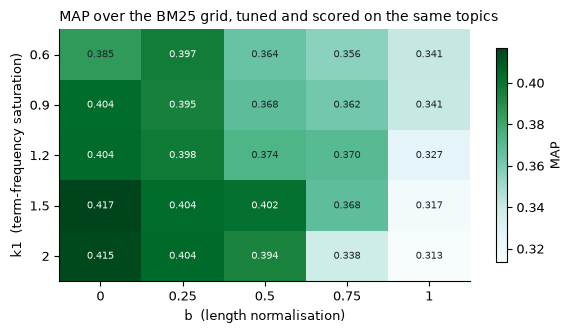

best cell     k1 = 1.5, b = 0    MAP 0.4167
default cell  k1 = 1.2, b = 0.75   MAP 0.3696
the default cell reproduces the headline bm25|title MAP exactly: True

best minus default                   +0.0471 MAP
worst to best across the whole grid  0.1033 MAP
BM25 minus course tf-idf (paired)    +0.0784 MAP [+0.0167, +0.1406]
tuning two parameters on the test set swings MAP by 1.3 times the difference the whole
ranker comparison in section 7 is about


In [25]:
from pipeline.constants import GRID_B, GRID_K1

grid = results["grid"]
matrix = np.array([[grid[(k1, b)] for b in GRID_B] for k1 in GRID_K1])

fig, ax = plt.subplots(figsize=(5.9, 3.4))
image = ax.imshow(matrix, cmap="BuGn", aspect="auto")
ax.set_xticks(range(len(GRID_B)), [f"{b:g}" for b in GRID_B])
ax.set_yticks(range(len(GRID_K1)), [f"{k1:g}" for k1 in GRID_K1])
ax.set_xlabel("b  (length normalisation)")
ax.set_ylabel("k1  (term-frequency saturation)")
ax.set_title("MAP over the BM25 grid, tuned and scored on the same topics")
ax.grid(visible=False)
threshold = matrix.min() + 0.75 * (matrix.max() - matrix.min())
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center", fontsize=7.5,
                color="#f4f8f5" if matrix[i, j] > threshold else INK)
fig.colorbar(image, ax=ax, shrink=0.85, label="MAP")
plt.show()

best_cell = max(((k1, b) for k1 in GRID_K1 for b in GRID_B), key=lambda cell: grid[cell])
best_map = grid[best_cell]
default_map = grid[(BM25_K1, BM25_B)]
swing = float(matrix.max() - matrix.min())
pair = next(p for p in results["comparisons"] if p["key"] == "bm25_vs_raw")

print(f"best cell     k1 = {best_cell[0]:g}, b = {best_cell[1]:g}    MAP {best_map:.4f}")
print(f"default cell  k1 = {BM25_K1:g}, b = {BM25_B:g}   MAP {default_map:.4f}")
print(f"the default cell reproduces the headline bm25|title MAP exactly:"
      f" {default_map == interval('bm25|title', 'map')['mean']}")
print()
print(f"best minus default                   {best_map - default_map:+.4f} MAP")
print(f"worst to best across the whole grid  {swing:.4f} MAP")
print(f"BM25 minus course tf-idf (paired)    {pair['mean_diff']:+.4f} MAP"
      f" [{pair['lo']:+.4f}, {pair['hi']:+.4f}]")
print(f"tuning two parameters on the test set swings MAP by"
      f" {swing / abs(pair['mean_diff']):.1f} times the difference the whole")
print("ranker comparison in section 7 is about")

Two things follow, and the second is the one worth carrying away.

The best cell turns length normalisation **off entirely**, and the whole low-`b` column is
high. That is legible from section 2: this slice is dominated by short market reports, and
normalising by length mostly punishes the long features that genuinely have more to say.
Whether it generalises past a one-month slice of one newspaper is exactly what 71 topics
cannot answer.

And the swing across the grid is larger than the difference between BM25 and the course
tf-idf that the previous section argued about. A parameter tuned on the test set buys more
apparent MAP than the entire choice of weighting — a good reason to distrust any published
comparison that does not say where its parameters came from. The number this project
reports as its BM25 result is the **default** cell, not the best one.

## 9. What this cannot tell you

1. **It is about 2.5 percent of the FT collection.** One month of 1991 against judgments
   made for a collection hundreds of times larger. Most relevant documents for most topics
   are in the part of the collection that is not here.
2. **Unjudged means not relevant.** The standard TREC pool convention (D5). Every metric
   here is therefore a lower bound of unknown tightness, and `judged@10` — around half for
   every run — says how much of a ranking the pool can even see.
3. **Half the evaluable topics have exactly one relevant document.** On such a topic
   average precision is a step function of where a single document lands: 1.0, or 0.5, or
   a thousandth. The mean of a metric shaped like that is fragile.
4. **The BM25 grid is tuned on the topics it is scored on.** The best cell is an upper
   bound, not a result, and section 8 reports it as one (R3).
5. **No phrase, proximity, expansion or relevance feedback.** Topic 352 fails because the
   paper wrote *the Channel tunnel* and the topic said *Chunnel*; no weighting fixes a term
   that is not in the vocabulary (R5).
6. **The stopword list is the one the course issued**, unchanged (D6). It keeps `mr`, the
   heaviest term in the index. It is a judgement call, not a fact.
7. **Porter over-stems and under-stems.** `commun` merges *community*, *communications* and
   *communism*; elsewhere words that belong together stay apart. Section 3 shows both.
8. **The corpus is 1991 English financial news.** Nothing here says how the same engine
   behaves on another language, another domain or another decade.
9. **Intervals, not significance.** Everything above is a 95 percent percentile bootstrap
   over topics. No hypothesis test is run and no p-value is reported, because the question
   was how uncertain these numbers are, not whether a threshold was cleared.
10. **It compares weightings, not engines.** The subject is the course's pipeline measured
    honestly against two better-known weightings. It is not a comparison against a modern
    retrieval system and nothing here should be read as one.

The notebook and the site are the same numbers, from the same functions. The site
compresses the argument into two minutes; this is the version that shows its work, so that
any figure on the page can be traced back to the code that produced it.